# Thermodynamic data

Workflows to generate Brouwer and doping diagrams are already wrapped in the `DefectsAnalysis.plot_brouwer_diagram` and `DefectsAnalysis.plot_doping_diagram` functions. However, other less general workflows can be easily implemented by using the `thermodynamics` and `plotter` modules.\
In this example, we look at the differences between donor and acceptor doping in $\mathrm{SrTiO_3}$ (**made-up** numbers). First we look at the doping diagrams generated with the wrapper functions, then we generate a plot showing how the vacancies concentrations change as a function of the concentrations of Fe and Nb. 

In [1]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 5,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 8.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 6,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 5.8,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': -4,'multiplicity': 1,'energy_diff': 20,'bulk_volume': bulk_volume},
{'name': 'Vac_Ti','charge': 0,'multiplicity': 1,'energy_diff': 19.7,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': -1,'multiplicity': 1,'energy_diff': 6.5,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': -2,'multiplicity': 1,'energy_diff': 7.5,'bulk_volume': bulk_volume},
{'name': 'Sub_Nb_on_Ti','charge': 1,'multiplicity': 1,'energy_diff': 2,'bulk_volume': bulk_volume},
{'name': 'Sub_Nb_on_Ti','charge': 0,'multiplicity': 1,'energy_diff': 3.5,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)
da.table(display=['energy_diff'])

,name,delta atoms,charge,multiplicity,corrections,energy_diff
0,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",-2,1,{},7.5
1,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",-1,1,{},6.5
2,Sub_Nb_on_Ti,"{'Nb': 1, 'Ti': -1}",0,1,{},3.5
3,Sub_Nb_on_Ti,"{'Nb': 1, 'Ti': -1}",1,1,{},2.0
4,Vac_O,{'O': -1},0,1,{},8.8
5,Vac_O,{'O': -1},2,1,{},5.0
6,Vac_Sr,{'Sr': -1},-2,1,{},6.0
7,Vac_Sr,{'Sr': -1},0,1,{},5.8
8,Vac_Ti,{'Ti': -1},-4,1,{},20.0
9,Vac_Ti,{'Ti': -1},0,1,{},19.7


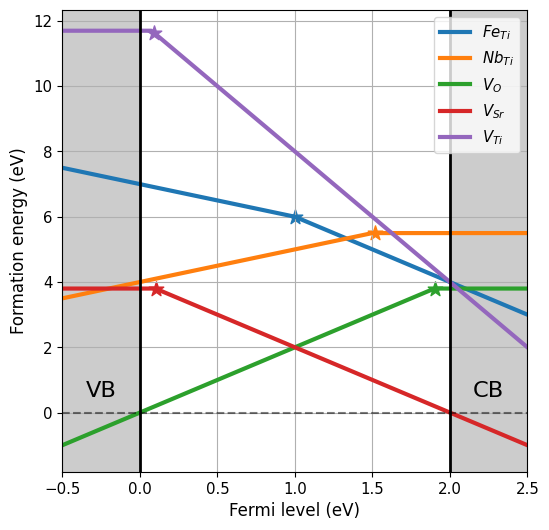

In [2]:
chempots = {'O':-5,'Sr':-2,'Fe':-8.5,'Ti':-8,'Nb':-10}
bulk_dos = {'m_eff_e':0.5,'m_eff_h':0.4}
da.plot_formation_energies(chempots);

In [3]:
# remove defect entries containing Nb
da_Fe = da.filter_entries(exclude=True,elements=['Nb'])
da_Fe

,name,delta atoms,charge,multiplicity,corrections
0,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",-2,1,{}
1,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",-1,1,{}
2,Vac_O,{'O': -1},0,1,{}
3,Vac_O,{'O': -1},2,1,{}
4,Vac_Sr,{'Sr': -1},-2,1,{}
5,Vac_Sr,{'Sr': -1},0,1,{}
6,Vac_Ti,{'Ti': -1},-4,1,{}
7,Vac_Ti,{'Ti': -1},0,1,{}


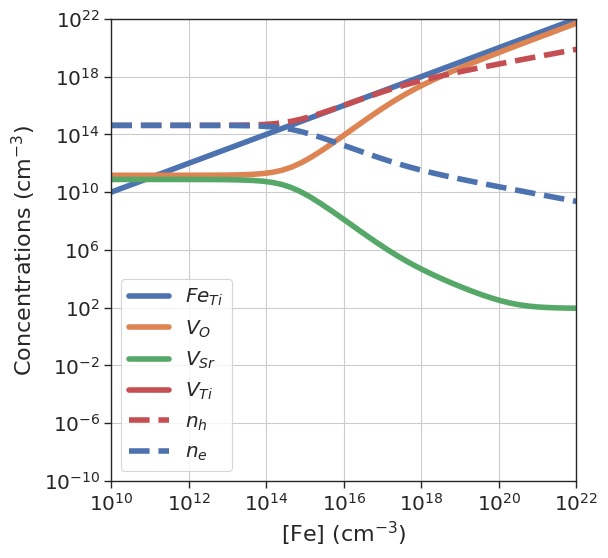

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns # optional

sns.set_theme(context='paper',style='ticks') # optional


da_Fe.plot_doping_diagram(
                    variable_defect_specie='Fe',
                    concentration_range=(1e10,1e22),
                    chemical_potentials=chempots,
                    bulk_dos=bulk_dos,
                    temperature=1000,
                    figsize=(6,6),
                    fontsize=16,
                    ylim=(1e-10,1e22)
                    );
data_Fe = da_Fe.thermodata # store thermodynamic data

In [5]:
# remove defect entries containing Fe
da_Nb = da.filter_entries(exclude=True,elements=['Fe'])
da_Nb

,name,delta atoms,charge,multiplicity,corrections
0,Sub_Nb_on_Ti,"{'Nb': 1, 'Ti': -1}",0,1,{}
1,Sub_Nb_on_Ti,"{'Nb': 1, 'Ti': -1}",1,1,{}
2,Vac_O,{'O': -1},0,1,{}
3,Vac_O,{'O': -1},2,1,{}
4,Vac_Sr,{'Sr': -1},-2,1,{}
5,Vac_Sr,{'Sr': -1},0,1,{}
6,Vac_Ti,{'Ti': -1},-4,1,{}
7,Vac_Ti,{'Ti': -1},0,1,{}


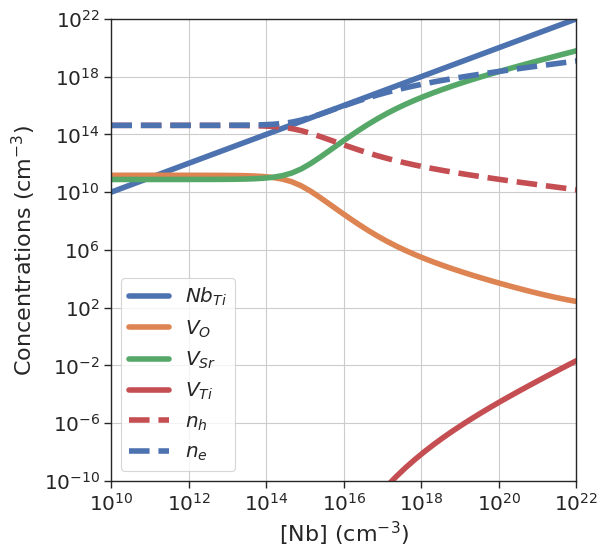

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns # optional

sns.set_theme(context='paper',style='ticks') # optional


da_Nb.plot_doping_diagram(
                    variable_defect_specie='Nb',
                    concentration_range=(1e10,1e22),
                    chemical_potentials=chempots,
                    bulk_dos=bulk_dos,
                    temperature=1000,
                    figsize=(6,6),
                    fontsize=16,
                    ylim=(1e-10,1e22)
                    );
data_Nb = da_Nb.thermodata # store thermodynamic data

Now we generate a plot showing both cases together. The thermodynamic data we stored is subscriptable like a dictionary, but we can also access keys as attributes.\
Dict that contains the thermodynamic data, typically output from the methods in the `DefectThermodynamics` class. In principle any key can be stored, for example when not running a default workflow from the `thermodynamics` class.

**Keys**:

- **partial_pressures** *(list)*  
  Partial pressure values.

- **variable_defect_specie** *(str)*  
  Name of variable defect species.

- **variable_concentrations** *(list)*  
  Concentrations of variable species.

- **defect_concentrations** *(list)*  
  `DefectConcentrations` objects (cm^-3).

- **carrier_concentrations** *(list)*  
  Tuples with intrinsic carrier concentrations *(holes, electrons)* in cm^-3.

- **conductivities** *(list)*  
  Conductivity values (in S/m).

- **fermi_levels** *(list)*  
  Fermi level values in eV.

- **temperatures** *(list)*  
  Temperature values in K.


The `ThermoData` object can be stored and recalled with the `to_json` and `from_json` methods.
Here we plot the total concentrations of $V_O$ and $V_{Sr}$ for the two doping cases, by calling the `total` attribute of `DefectConcentrations` objects.

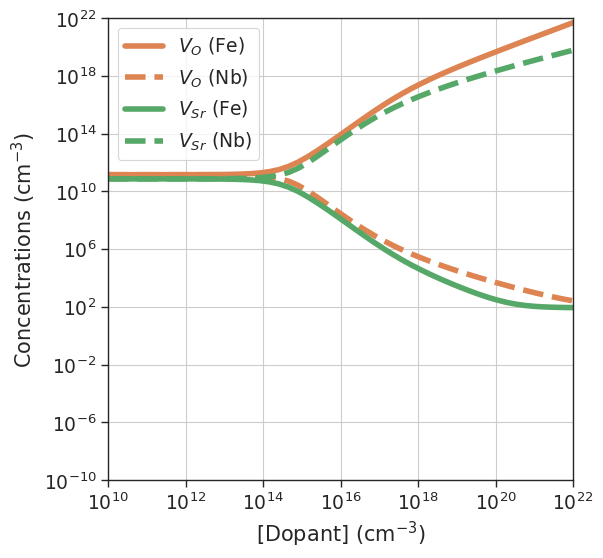

In [7]:
from defermi.plotter import plot_x_vs_concentrations
import matplotlib

fig,ax = plt.subplots(figsize=(6,6))
fontsize = 15

X = data_Fe.variable_concentrations # Nb are equivalent

# get individual total concentrations
Vac_O_Fe = [c.total['Vac_O'] for c in data_Fe.defect_concentrations]
Vac_O_Nb = [c.total['Vac_O'] for c in data_Nb.defect_concentrations]
Vac_Sr_Fe = [c.total['Vac_Sr'] for c in data_Fe.defect_concentrations]
Vac_Sr_Nb = [c.total['Vac_Sr'] for c in data_Nb.defect_concentrations]

ax.plot(X,Vac_O_Fe,linewidth=4,label='$V_{O}$ (Fe)',color='C1')
ax.plot(X,Vac_O_Nb,'--',linewidth=4,label='$V_{O}$ (Nb)',color='C1')

ax.plot(X,Vac_Sr_Fe,linewidth=4,label='$V_{Sr}$ (Fe)',color='C2')
ax.plot(X,Vac_Sr_Nb,'--',linewidth=4,label='$V_{Sr}$ (Nb)',color='C2')

ax.tick_params(axis='both', labelsize=fontsize*0.9)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('[Dopant] (cm$^{-3})$',fontdict={'size':fontsize})
plt.ylabel('Concentrations (cm$^{-3})$',fontdict={'size':fontsize})
plt.xlim(1e10,1e22)
plt.ylim(1e-10,1e22)
plt.legend(loc='upper left',prop={'size':0.9*fontsize})
plt.grid()


In this next example, we compute the charge carriers concentrations in different annealing conditions for the intrinsic material. We compute the quenched defect equilibrium for different temperatures, quenching to room temperature.  To do this, we call the `get_single_point_quenched_thermodata` method of the `DefectThermodynamics` class, which returns a `ThermoData` object for a specific set of conditions (chemical potentials, temperature, fixed concentrations ,etc). The data is then plotted with the `plot_x_vs_concentrations` function in the `plotter` module, which automates the formatting for the concentrations while keeping a generic x-asis. We set the temperature values as x-axis.  

In [8]:
# remove entries containing fe and Nb
da_int = da.filter_entries(exclude=True,elements=['Fe','Nb'])

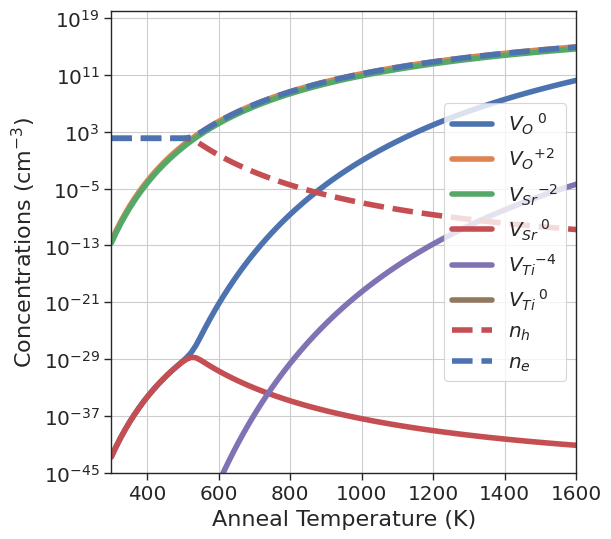

In [ ]:
from defermi.thermodynamics import DefectThermodynamics, ThermoData
import numpy as np

dt = DefectThermodynamics(defects_analysis=da_int,bulk_dos=bulk_dos)
T_range = (300,1600)
temperatures = np.linspace(T_range[0],T_range[1],100)
defect_concentrations = []
carrier_concentrations = []

for T in temperatures:
    thermodata = dt.get_single_point_quenched_thermodata(
                                        chemical_potentials=chempots,
                                        initial_temperature=T,
                                        final_temperature=300)
    
    defect_concentrations.append(thermodata.defect_concentrations)
    carrier_concentrations.append(thermodata.carrier_concentrations)


from defermi.plotter import plot_x_vs_concentrations

plot_x_vs_concentrations(
            x=temperatures,
            xlabel='Anneal Temperature (K)',
            defect_concentrations=defect_concentrations,
            carrier_concentrations=carrier_concentrations,
            output='all', # choose output for defect concentrations
            xlim=T_range,
            ylim=(1e-45,1e20),
            figsize=(6,6),
            fontsize=16);